#Import Library

In [5]:
import os
import numpy as np
import random
import cv2
import pandas as pd
import seaborn as sns
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

#Load Dataset

In [6]:
# Pastikan file kaggle.json sudah di-upload ke Colab
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri

# Ekstrak file zip
local_zip = 'brain-tumor-classification-mri.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/dataset_mri')
zip_ref.close()

base_dir = '/content/dataset_mri/Training'
classes = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
brain-tumor-classification-mri.zip: Skipping, found more recently modified local copy (use --force to force download)


#Exploratory Data Analysis (EDA)

In [7]:
base_dir = '/content/dataset_mri/Training'
classes = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

DISTRIBUSI DATA

/tmp/ipykernel_7195/3868264204.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Kelas', y='Jumlah Gambar', data=df_counts, palette='mako')


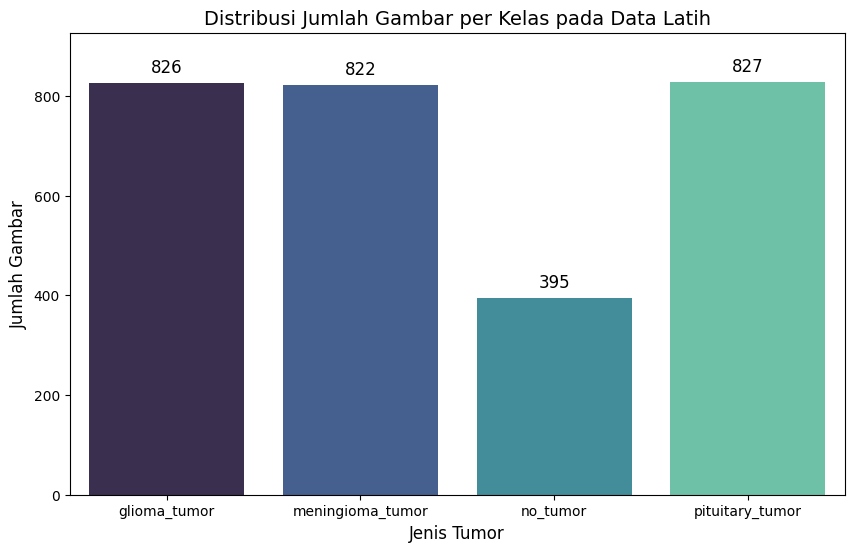

In [18]:
data_counts = []

for class_name in classes:
    class_path = os.path.join(base_dir, class_name)
    count = len(os.listdir(class_path))
    data_counts.append({'Kelas': class_name, 'Jumlah Gambar': count})

df_counts = pd.DataFrame(data_counts)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Kelas', y='Jumlah Gambar', data=df_counts, palette='mako')
plt.title('Distribusi Jumlah Gambar per Kelas pada Data Latih', fontsize=14)
plt.xlabel('Jenis Tumor', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, max(df_counts['Jumlah Gambar']) + 100)
plt.show()

RESOLUSI GAMBAR

Sedang membaca dimensi gambar, mohon tunggu sebentar...


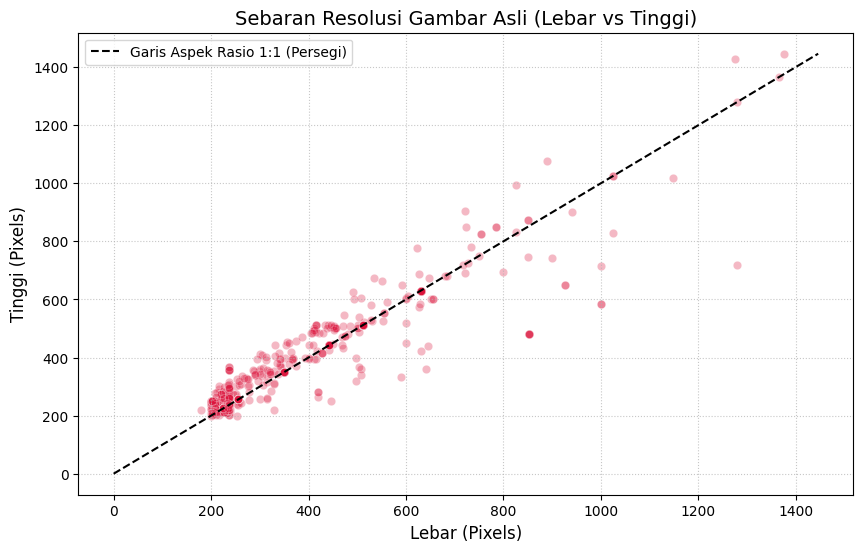

Resolusi Terkecil: 180x198
Resolusi Terbesar: 1375x1446


In [17]:
widths = []
heights = []

print("Sedang membaca dimensi gambar, mohon tunggu sebentar...")
for class_name in classes:
    class_path = os.path.join(base_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        # Baca gambar menggunakan OpenCV
        img = cv2.imread(img_path)
        if img is not None:
            height, width, _ = img.shape
            widths.append(width)
            heights.append(height)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.3, color='crimson')
plt.title('Sebaran Resolusi Gambar Asli (Lebar vs Tinggi)', fontsize=14)
plt.xlabel('Lebar (Pixels)', fontsize=12)
plt.ylabel('Tinggi (Pixels)', fontsize=12)

max_val = max(max(widths), max(heights))
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', label='Garis Aspek Rasio 1:1 (Persegi)')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

print(f"Resolusi Terkecil: {min(widths)}x{min(heights)}")
print(f"Resolusi Terbesar: {max(widths)}x{max(heights)}")

SAMPLE GAMBAR

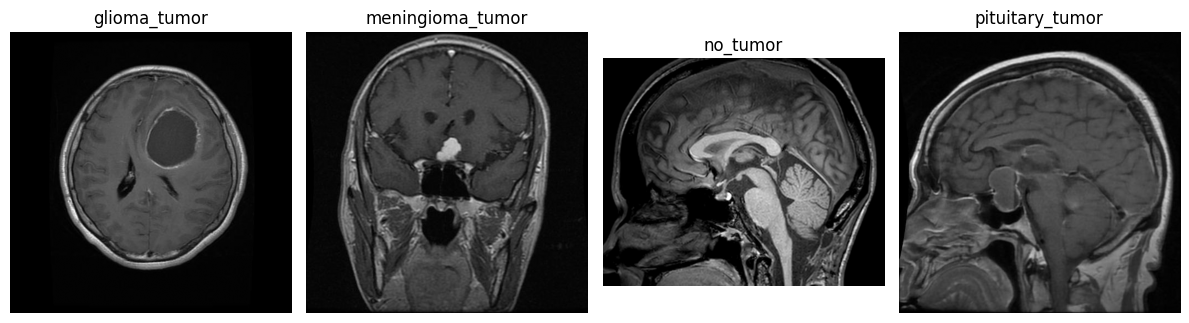

In [10]:
plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):
    path = os.path.join(base_dir, cls)
    img_name = random.choice(os.listdir(path))
    img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)

    plt.subplot(1,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

INTENSITAS PIKSEL

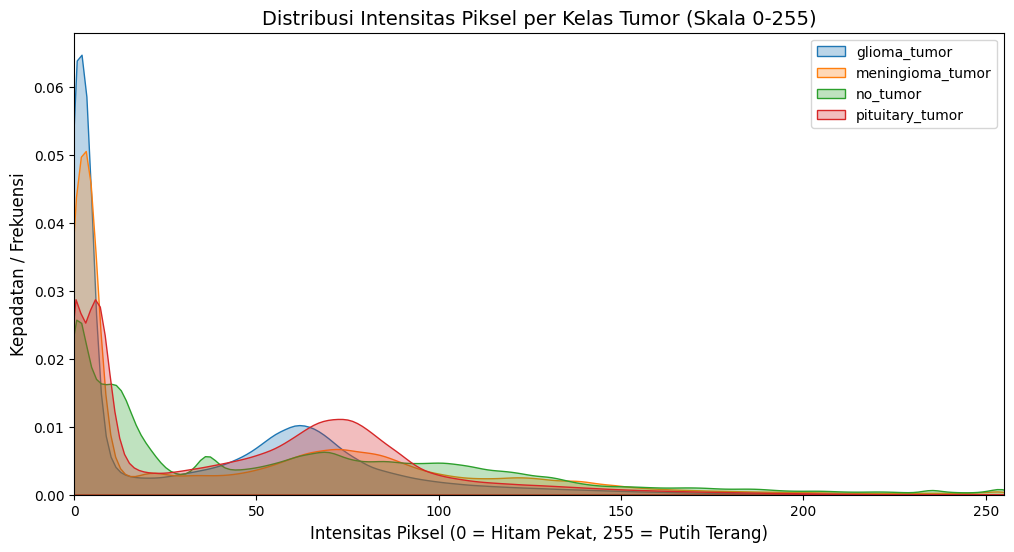

In [11]:
plt.figure(figsize=(12, 6))

for class_name in classes:
    class_path = os.path.join(base_dir, class_name)
    sample_images = random.sample(os.listdir(class_path), 50)

    class_pixels = []
    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            class_pixels.extend(img.flatten())

    sns.kdeplot(class_pixels, label=class_name, fill=True, alpha=0.3)

plt.title('Distribusi Intensitas Piksel per Kelas Tumor (Skala 0-255)', fontsize=14)
plt.xlabel('Intensitas Piksel (0 = Hitam Pekat, 255 = Putih Terang)', fontsize=12)
plt.ylabel('Kepadatan / Frekuensi', fontsize=12)
plt.xlim(0, 255)
plt.legend()
plt.show()

# Data Preparation

In [12]:
train_dir = '/content/dataset_mri/Training'
test_dir = '/content/dataset_mri/Testing'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


# Modelling

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze sebagian layer
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.6)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 2,019,588 (7.70 MB)

 Non-trainable params: 402,880 (1.54 MB)

# Callback

In [14]:
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True),
    ReduceLROnPlateau(factor=0.3, patience=3)
]

# Training

In [15]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.4421 - loss: 3.7260

72/72 ━━━━━━━━━━━━━━━━━━━━ 103s 994ms/step - accuracy: 0.5599 - loss: 3.3850 - val_accuracy: 0.4939 - val_loss: 3.5536 - learning_rate: 5.0000e-05
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 475ms/step - accuracy: 0.7893 - loss: 2.8168 - val_accuracy: 0.5340 - val_loss: 3.5966 - learning_rate: 5.0000e-05
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 484ms/step - accuracy: 0.8511 - loss: 2.6005 - val_accuracy: 0.5707 - val_loss: 3.8977 - learning_rate: 5.0000e-05
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8918 - loss: 2.4656

72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 489ms/step - accuracy: 0.8881 - loss: 2.4628 - val_accuracy: 0.6370 - val_loss: 3.3390 - learning_rate: 5.0000e-05
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9183 - loss: 2.3667

72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 490ms/step - accuracy: 0.9138 - loss: 2.3412 - val_accuracy: 0.6894 - val_loss: 3.1028 - learning_rate: 5.0000e-05
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 472ms/step - accuracy: 0.9321 - loss: 2.2423 - val_accuracy: 0.6841 - val_loss: 3.2863 - learning_rate: 5.0000e-05
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9478 - loss: 2.1523

72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 490ms/step - accuracy: 0.9443 - loss: 2.1409 - val_accuracy: 0.7016 - val_loss: 3.0833 - learning_rate: 5.0000e-05
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9496 - loss: 2.0918

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 497ms/step - accuracy: 0.9974 - loss: 0.4199 - val_accuracy: 0.8831 - val_loss: 1.0149 - learning_rate: 1.5000e-05
Epoch 44/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 483ms/step - accuracy: 0.9991 - loss: 0.4099 - val_accuracy: 0.8778 - val_loss: 1.0236 - learning_rate: 1.5000e-05
Epoch 45/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9988 - loss: 0.4021

72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 480ms/step - accuracy: 0.9983 - loss: 0.4021 - val_accuracy: 0.8778 - val_loss: 1.0045 - learning_rate: 1.5000e-05
Epoch 46/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9996 - loss: 0.3960

72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 501ms/step - accuracy: 0.9983 - loss: 0.3954 - val_accuracy: 0.8831 - val_loss: 1.0000 - learning_rate: 1.5000e-05
Epoch 47/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 495ms/step - accuracy: 0.9983 - loss: 0.3881 - val_accuracy: 0.8831 - val_loss: 1.0152 - learning_rate: 1.5000e-05
Epoch 48/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9976 - loss: 0.3823

72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 497ms/step - accuracy: 0.9983 - loss: 0.3786 - val_accuracy: 0.8796 - val_loss: 0.9865 - learning_rate: 1.5000e-05
Epoch 49/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 471ms/step - accuracy: 0.9983 - loss: 0.3729 - val_accuracy: 0.8796 - val_loss: 1.0012 - learning_rate: 1.5000e-05
Epoch 50/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9982 - loss: 0.3647

72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 484ms/step - accuracy: 0.9991 - loss: 0.3624 - val_accuracy: 0.8831 - val_loss: 0.9783 - learning_rate: 1.5000e-05


# Evaluation

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 391ms/step - accuracy: 0.7538 - loss: 2.1057
Test Accuracy: 75.38%
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 408ms/step


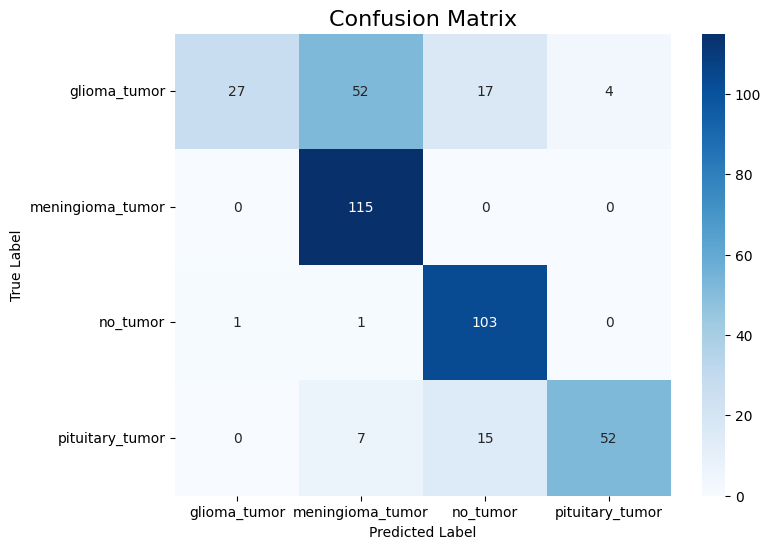

              precision    recall  f1-score   support

           0       0.96      0.27      0.42       100
           1       0.66      1.00      0.79       115
           2       0.76      0.98      0.86       105
           3       0.93      0.70      0.80        74

    accuracy                           0.75       394
   macro avg       0.83      0.74      0.72       394
weighted avg       0.81      0.75      0.72       394



In [19]:
best_model = load_model('best_model.h5')

test_gen.reset()
loss, acc = best_model.evaluate(test_gen)

print(f"Test Accuracy: {acc*100:.2f}%")

# Predict
test_gen.reset()
preds = best_model.predict(test_gen)

y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

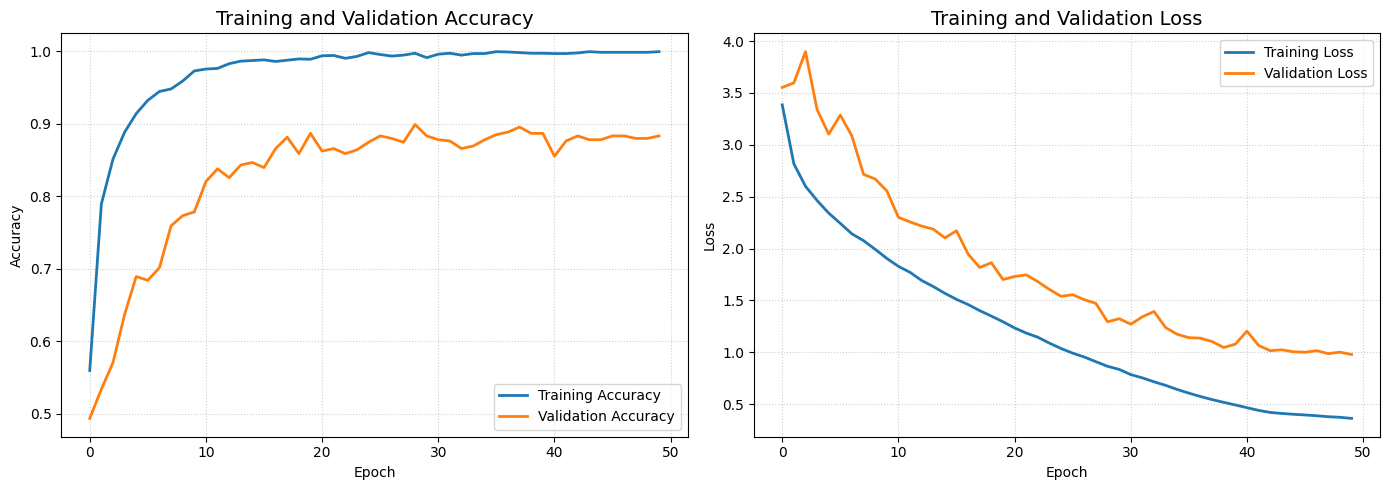

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()